# Proyecto final - Programación Probabilística

---

### Modelo: Regresión Logística Bayesiana Jerárquica  
### Tema: Surtimiento de Recetas a Nivel Nacional 2019-2023

---

Oscar David Ostorga Flores - A01551528

Juan Alejandro Méndez Vargas - A01362165

---

# 1. Problema de política pública

## 1.1 El derecho a la salud en un sistema fragmentado

El acceso a medicamentos es una condición necesaria para ejercer el derecho humano a la salud (Art. 4º constitucional[cita]). En México, el Sistema Nacional de Salud  está **fragmentado y segmentado**. Por un lado, distintas instituciones (IMSS, ISSSTE, IMSS-Bienestar, SSA, SEDENA, SEMAR, PEMEX, los Servicios Estatales de Salud, y Universidades) atienden a poblaciones distintas según su condición laboral o socioeconómica. Por otro, cada subsistema cuenta con sistemas de información, presupuestos y cadenas de suministro independientes entre sí. Esta fragmentación y segmentación son las razones principal por las que una pregunta aparentemente simple —¿cuántas recetas no se surten en México?— no tiene una respuesta sencilla de estimar .

---

## 1.2 ¿Qué es una receta "no surtida"?

Siguiendo la clasificación que usan los propios subsistemas de salud, el Observatorio Mexicano de Acceso a Medicamentos e Insumos Médicos (OCAMIS) y el Colectivo Cero Desabasto (Nosotr@s por la Democracia y Colectivo Cero Desabasto, 2023):

- **Receta presentada**: la prescrita por personal médico a un paciente derechohabiente.
- **Receta surtida (totalmente)**: se entregaron todos los medicamentos prescritos.
- **Receta surtida parcialmente**: falta uno o más medicamentos.
- **Receta negada**: no se surtió ningún medicamento.
- **No surtida efectivamente** = parciales + negadas.

Este proyecto modela exactamente esa ultima categoria binaria a nivel folio: *¿salió el paciente con toda su medicación (θ) o no?* 

---

## 1.3 Magnitud del problema al cierre de 2023

De acuerdo con la *Radiografía del Desabasto de Medicamentos en México 2023* (con base en solicitudes de transparencia a las propias instituciones de salud), en 2023 las cinco instituciones de seguridad social más grandes reportaron:

| Institución | Recetas no surtidas efectivamente (2023) | % de surtimiento |
|---|---:|---:|
| IMSS      | 5,185,877 | 98.0% |
| ISSSTE    |   746,017 | 98.1% |
| SEMAR     |   156,050 | 84.3% |
| SEDENA    |   931,364 | 73.9% |
| PEMEX     |   484,510 | 90.0% |
| **Total** | **7,503,818** | — |

El peor año fue 2021 (pico de la pandemia + desaparición del Seguro Popular / creación del INSABI), cuando tan solo el IMSS dejó 22.06 millones de recetas sin surtir efectivamente (el mes más crítico julio-agosto 2021, cerró con apenas 87% de surtimiento completo). El sistema muestra una recuperación sostenida desde
entonces, pero **SEDENA es la única institución que empeoró entre 2022 y 2023** (de 77.7% a 73.9%), mientras el resto mejora.

Por su parte, el Censo 2020 (INEGI) reportó que **más de 31 millones de personas** carecen de acceso a servicios médicos en México, altamente relacionado con el hecho que México gasta apenas 5.5% de su PIB en salud (el más bajo de América Latina). Asimismo, México ocupa el 4º lugar de la OCDE en gasto de bolsillo en medicamentos; es decir, cuando el sistema público falla, el costo se traslada directamente a los hogares, y de forma más que proporcional a los más pobres (5.8% de los hogares del quintil más pobre incurren en gasto catastrófico en salud, vs. 2.9% del quintil más rico).

---

## 1.4 La brecha civil-militar y la diferencia geográfica

Dos patrones saltan a la vista en la Radiografía 2023 realizada por el colectivo Cero Desabasto:

1. **Brecha civil-militar**: IMSS (98.0%) e ISSSTE (98.1%) surten consistentemente mejor que SEDENA (73.9%) y SEMAR (84.3%). Esta no es una anomalía de un año: la brecha es estructural y persiste en el tiempo.
2. **Heterogeneidad geográfica**: en 2023, Chihuahua fue sistemáticamente el peor estado en surtimiento del IMSS (93.7%, el único por debajo de 94%), y los Servicios Estatales de Salud (SESA) de Aguascalientes y Chihuahua reportaron surtimientos de apenas 37.4% y 51.6% respectivamente, muy por debajo del resto del país.

**Ambos patrones son precisamente los que este proyecto busca cuantificar a partir de un enfoque bayesiano, en lugar de solo reportar porcentajes puntuales.**

---

## 1.5 Consecuencias del desabasto

La Radiografía documenta un aumento sostenido de **amparos** promovidos por pacientes para forzar el acceso efectivo a medicinas (ISSSTE pasó de 16 amparos en 2017 a 234 en 2023), relacionado con una crisis aguda de falta de medicamentos psiquiátricos tras la suspensión de Psicofarma por COFEPRIS en 2022 (más de 760 reportes en dos años, encabezando la lista de padecimientos afectados). Esto fue acompañaod por un incremento de reportes de **medicamentos falsificados o robados** (de 26 en 2018 a 218 en 2022). Los testimonios de pacientes recopilados en la plataforma cerodesabasto.org (conformada por colectivos con distintos padecimientos como lupus, cáncer, epilepsia, esquizofrenia, VIH, entre otras) ilustran que detrás de cada punto porcentual de "no surtimiento" hay miles —incluso millones— de decisiones de vida o muerte, gasto de bolsillo forzado, riesgo de recaída o abandono de tratamiento.

---

## 1.6 Pregunta de investigación de este proyecto

> **¿Cuál es la probabilidad de que un paciente salga con toda su medicación (θ), y cómo varía por institución, estado y año?**

A diferencia de un reporte descriptivo de porcentajes (estadística frecuentista), el enfoque bayesiano jerárquico permite: 

* (i) compartir información entre estados/años/instituciones con pocos datos (partial pooling)
* (ii) cuantificar la **incertidumbre** de cada estimación en vez de solo su punto central 
* (iii) responder preguntas de probabilidad directamente interpretables para política pública (p. ej. *P(θ_civil > θ_militar) = 100%*), algo que un simple cociente de recetas surtidas / presentadas no puede ofrecer.


---

## 1.7 Justificación del proyecto con base en la evidencia proporcionada por Cero Desabasto

Este proyecto usa una base de datos propia (`data/base_modelo_2019_2023.csv`), construida de forma independiente a partir de solicitudes de transparencia directas a IMSS, IMSS-Bienestar, ISSSTE, SEDENA y SEMAR para el período 2019-2023, desagregada por folio a nivel estado-año- institución. No es la misma base que usa la Radiografía del Desabasto (que cubre más instituciones —PEMEX, SESA, hospitales de alta especialidad— con otra ventana temporal), pero **ambas fuentes son independientes y convergen en el mismo hallazgo central**: una brecha sostenida de calidad de surtimiento entre el sistema civil y el militar, y una fuerte heterogeneidad geográfica dentro de cada institución. Esa convergencia entre dos fuentes de datos distintas es, en sí misma, evidencia de robustez del hallazgo.

*Nota: las solicitudes de información originales (incluidas las respuestas formales de cada insitución) pueden ser consultadas en la carpeta `data/solicitudes` dentro del repositorio.* 


# 2: Carga de datos y preparación de modelos

In [1]:
# 2.1 Paqueterias y definición de direcciones de trabajo

import pathlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az 
import pymc as pymc
from IPython.display import Image

%load_ext autoreload
%autoreload 2

_cwd = pathlib.Path().resolve()
ROOT = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_DIR = ROOT / 'data'
IDATA_DIR = DATA_DIR / 'idata'

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"IDATA_DIR: {IDATA_DIR}")

# 2.2 Carga de la base de datos 

df = pd.read_csv(DATA_DIR / 'base_modelo_2019_2023.csv')
print(f'La base cuenta con {df.shape[0]} filas y {df.shape[1]} columnas')
print(df.head())

# 2.3 Preparación de datos para el modelo 

from model_data import preparar_modelo_a, preparar_modelo_c

data_a = preparar_modelo_a(df)
data_c = preparar_modelo_c(df)

print('Modelo A — coords:', {k: len(v) for k, v in data_a['coords'].items()})
print('Modelo C — coords:', {k: len(v) for k, v in data_c['coords'].items()})
print('mask_civil:', data_c['mask_civil'])
print('mask_mil  :', data_c['mask_mil'])
assert data_c['mask_civil'].sum() == 3
assert data_c['mask_mil'].sum() == 2
print('OK — dimensiones esperadas')



ROOT: /Users/main/Documents/ciencia_de_datos/Programacion probabilistica/final-project-pp-dj
DATA_DIR: /Users/main/Documents/ciencia_de_datos/Programacion probabilistica/final-project-pp-dj/data
IDATA_DIR: /Users/main/Documents/ciencia_de_datos/Programacion probabilistica/final-project-pp-dj/data/idata
La base cuenta con 576 filas y 6 columnas
           estado  anio  surtidas    total institucion   tipo
0  AGUASCALIENTES  2019   4334260  4338906        IMSS  civil
1  AGUASCALIENTES  2020   3676230  3803608        IMSS  civil
2  AGUASCALIENTES  2021   3874201  4163315        IMSS  civil
3  AGUASCALIENTES  2022   4382755  4557129        IMSS  civil
4  AGUASCALIENTES  2023   4971284  5053481        IMSS  civil
Modelo A — coords: {'estado': 32, 'anio': 5, 'institucion': 3, 'tipo': 1}
Modelo C — coords: {'estado': 32, 'anio': 5, 'institucion': 5, 'tipo': 2, 'inst_civil': 3, 'inst_mil': 2}
mask_civil: [ True  True  True False False]
mask_mil  : [False False False  True  True]
OK — dimension

Los datos de surtimiento de recetas para **IMSS, IMSS Bienestar, SEDENA y SEMAR** se obtuvieron mediante solicitudes de acceso a la información pública presentadas ante la Plataforma Nacional de Transparencia (INAI) y dirigidas directamente a cada institución. Cada archivo fuente conserva en su propio nombre el folio de la solicitud correspondiente (por ejemplo, `data/IMSS_2019_ABRIL2024_ANUAL_SOLICITUD 330018024016694 ANEXO I.xlsx` ), lo que permite trazar y verificar el origen oficial de cada dataset. Para el **ISSSTE**, se accedió directamente a microdatos  de surtimiento desagregados por folio de receta a través del **Sistema Integral de Abasto de Medicamentos (SIAM)**, el sistema institucional propio del ISSSTE para el control de abasto, mediante un permiso de acceso temporal otorgado por el INAI. Estos microdatos se agregaron a nivel estado-año antes de integrarse a la base (`agg_folio_2018_2024.csv`).

A partir de estas cinco fuentes heterogéneas, el módulo `src/load_data.py` construye la base unificada del modelo mediante un *loader* por institución (`load_issste`, `load_imss`, `load_imss_bienestar`, `load_sedena`, `load_semar`) que resuelve el formato crudo particular de cada una: el CSV mensual del ISSSTE se colapsa a nivel anual; el Excel del IMSS se lee directamente de la hoja `Recetas`; el de IMSS Bienestar —en formato ancho, con la fila de encabezado en una posición variable por hoja— se despivotea (`melt`) por año; SEDENA reporta por hospital y no por estado, por lo que el estado se reconstruye a partir de abreviaturas embebidas en el nombre del hospital más un catálogo manual de excepciones, y luego se agrega a nivel estado-año; y SEMAR viene en un pivote ancho por hoja (`DH` referente a derechohabientes), donde se localizan programáticamente las columnas de total anual por estado. Cada *loader* normaliza los nombres de estado a la nomenclatura canónica del ISSSTE y devuelve un esquema común (`estado, anio, surtidas, total, institucion`). La función `load_all()` concatena los cinco datasets, añade la columna `tipo` (civil/militar) según la institución, y entrega el panel completo. Sobre ese panel, el notebook de carga (`carga_datos.ipynb`) filtra la ventana comparable 2019-2023 —excluyendo 2024 por estar incompleto y los años previos en los que el IMSS no reporta— y descarta filas sin recetas presentadas, generando finalmente `data/base_modelo_2019_2023.csv`, la base de 576 filas que alimenta el modelo jerárquico.

---

**Nota sobre la calidad de datos de IMSS-BIENESTAR: en el caso particular de esta institución, la información otorgada directamente en la respuesta a la solicitud de información unicamente incluye las recetas presentadas en el segundo nivel de atención.** Dado que no se cuenta con alguna otra solicitud que complemente para el nivel primario de atención, se decidió usar esta información parcial para alimentar el modelo. Para **mejorar** el modelo, se podrían hacer nuevas solicitudes de información para complementar la información acutal. 

**Nota sobre la calidad de datos de SEDENA: para esta institución, la respuesta a la solicitud de información fue parcialmente inexistente, argumentando que el sistema unicamente contaba con el historico de un año previo; es decir, cubre unicamente 2022 y 2023.**

---

Para efectos prácticos, este notebook corre directamente con la base final `data/base_modelo_2019_2023.csv`, pero si se quiere replicar el resultado, basta con correr `carga_datos.ipynb`. 

In [2]:
print('Proceso de obtención y carga de información')
Image(filename="../imgs/Data_access_pipeline.png")


Proceso de obtención y carga de información


# 3. Detalle del modelo y proceso de inferencia

## Pregunta de investigación

> **¿Cuál es la probabilidad de que un paciente salga con toda su medicación (θ), y cómo varía por institución, estado y año?**

## 3.1 Unidad de análisis y datos

La unidad de análisis es el **recetas agregadas** a nivel *estado - año - institución* (no la receta individual). Cada fila de `base_modelo_2019_2023.csv` contiene `total` (recetas presentadas) y `surtidas` (recetas surtidas por completo) para una combinación única de estado, año e institución, para los años 2019-2023, en 5 instituciones, con un total de 576 filas. Este nivel de agregación es el que permiten los datos oficiales disponibles (a excepción del ISSSTE, las demás instituciones no comparten microdatos por folio o medicamento).

---

## 3.2 Por qué regresión logística jerárquica

El modelo de este proyecto es una **regresión logística bayesiana jerárquica con verosimilitud Binomial**: porque permite estimar los efectos de cada factor en escala logit y se **suman**, lo que permite descomponer el surtimiento en sus fuentes (tipo, institución, año, estado) de forma interpretable.

---

## 3.3 Especificación del modelo (Modelo C — modelo final)

$$
\text{logit}(\theta_i) = \beta_0 + \text{eff\_tipo}[\text{tipo}_i] +
\text{dev\_dentro\_tipo}[\text{inst}_i] + \text{eff\_anio}[\text{anio}_i] +
\text{eff\_estado}[\text{estado}_i]
$$
$$
k_i \sim \text{Binomial}(n_i, \theta_i)
$$

donde, para la fila $i$: $n_i$ = recetas presentadas, $k_i$ = recetas surtidas, $\theta_i$ =
probabilidad de surtimiento completo. `eff_tipo` tiene 2 niveles (civil, militar);
`dev_dentro_tipo` son las desviaciones de cada institución respecto al nivel de su tipo (3
niveles civiles: IMSS, IMSS Bienestar, ISSSTE; 2 niveles militares: SEDENA, SEMAR); `eff_anio`
tiene 5 niveles (2019-2023); `eff_estado` hasta 32 niveles.

---

### Nota metodológica: de un modelo simple a la estructura civil-militar
El modelo final (**modelo_C**) no fue el punto de partida, se llegó a el de forma incremental. En un primer momento, se ajustó un modelo más simple **sin distinguir tipo civil/militar**, usando únicamente las tres instituciones civiles (IMSS, IMSS Bienestar, ISSSTE) para validar que el modelo convergiera correctamente antes de introducir la complejidad de la estructura anidada:

$$
\text{logit}(\theta_i) = \beta_0 + \text{eff\_inst}[\text{inst}_i] +
\text{eff\_anio}[\text{anio}_i] + \text{eff\_estado}[\text{estado}_i]
$$
$$
k_i \sim \text{Binomial}(n_i, \theta_i)
$$

Aquí `eff_inst` es un único `ZeroSumNormal` plano de 3 niveles (IMSS, IMSS Bienestar, ISSSTE), sin distinción de tipo ni anidamiento (la versión más sencilla de la jerarquía).

Una vez que se confirmó convergencia (R-hat ≈ 1.00, 0 divergencias), se decidió escalar el modelo en complejidad de forma incremental: primero, incorporando SEDENA y SEMAR, y luego la distinción civil/militar con `dev_dentro_tipo` anidado dentro de `eff_tipo`— hasta llegar al **modelo_C**, que es el modelo final usado en el resto de este notebook. Aunque **modelo_A** no es el foco del análisis aquí, se incluye en esta nota como referencia para quien quiera comparar ambas especificaciones o entender el proceso incremental de construcción del modelo.



Diagrama del modelo logístico bayesiano jerárquico: estructura civil-militar - <pymc.model.core.Model object at 0x125a2ec10>


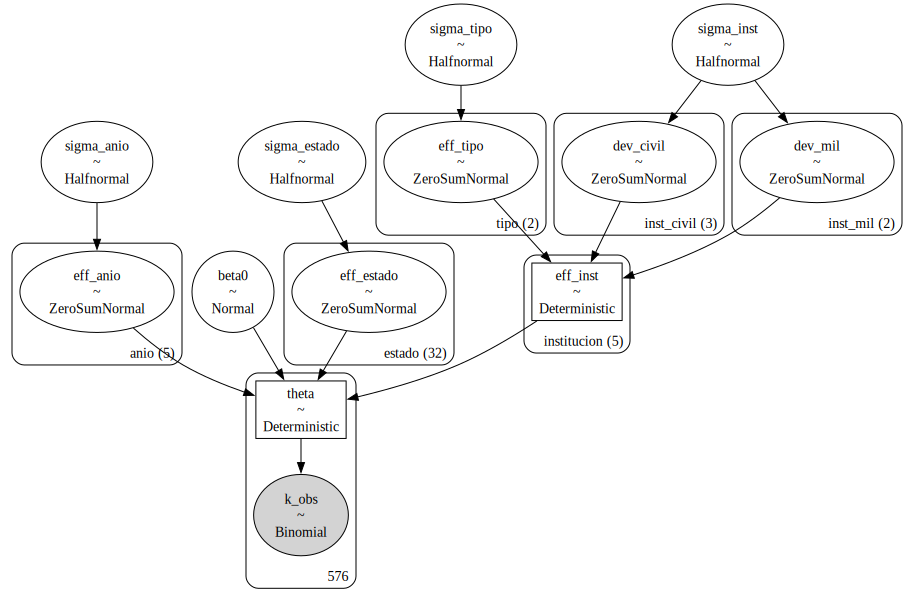

In [3]:
from models import build_modelo_a, build_modelo_c

modelo_A = build_modelo_a(data_a)
modelo_C = build_modelo_c(data_c)

print(f'Diagrama del modelo logístico bayesiano jerárquico: estructura civil-militar - {modelo_C}')
pymc.model_to_graphviz(modelo_C)

## 3.4 Código del modelo 

Modularizado en: `src/models.py - build_modelo_c`

```python

    coords = data["coords"]
    mask_civil = data["mask_civil"]
    mask_mil = data["mask_mil"]
    n_inst = len(coords["institucion"])

    with pymc.Model(coords = coords) as modelo_C:
        beta0 = pymc.Normal("beta0", mu = np.log(p_prior / (1 - p_prior)), sigma = 0.5)

        sigma_estado = pymc.HalfNormal("sigma_estado", sigma = 0.5)
        eff_estado = pymc.ZeroSumNormal("eff_estado", sigma = sigma_estado, dims = "estado")

        sigma_anio = pymc.HalfNormal("sigma_anio", sigma = 0.3)
        eff_anio = pymc.ZeroSumNormal("eff_anio", sigma = sigma_anio, dims = "anio")

        sigma_tipo = pymc.HalfNormal("sigma_tipo", sigma = 0.5)
        eff_tipo = pymc.ZeroSumNormal("eff_tipo", sigma = sigma_tipo, dims = "tipo")

        sigma_inst = pymc.HalfNormal("sigma_inst", sigma = 0.3)
        dev_civil = pymc.ZeroSumNormal("dev_civil", sigma = sigma_inst, dims = "inst_civil")
        dev_mil = pymc.ZeroSumNormal("dev_mil", sigma = sigma_inst, dims = "inst_mil")

        # Ensamblar dev_civil / dev_mil en el orden de coords["institucion"]

        dev_dentro = ptt.zeros(n_inst)
        dev_dentro = ptt.set_subtensor(dev_dentro[np.where(mask_civil)[0]], dev_civil)
        dev_dentro = ptt.set_subtensor(dev_dentro[np.where(mask_mil)[0]], dev_mil)

        eff_inst = pymc.Deterministic("eff_inst", eff_tipo[data["inst_to_tipo"]] + dev_dentro, dims = "institucion")

        logit_theta = (beta0 + eff_estado[data["estado_idx"]] + eff_anio[data["anio_idx"]] + eff_inst[data["inst_idx"]])

        theta = pymc.Deterministic("theta", pymc.math.invlogit(logit_theta))
        
        pymc.Binomial("k_obs", n = data["n_obs"], p = theta, observed = data["k_obs"])

        return modelo_C
```
---

## 3.5 Priors e hiperpriors, y por qué se eligieron

Con la intención de alimentar el modelo con un prior informado, se realizó un prior predictive check y se probaron distintos parametros. Esto derivo en la siguiente composición para el modelo final:

---

```python
p = 0.89  # promedio observado del sistema (abasto nacional)
beta0 = pm.Normal("beta0", mu=np.log(p/(1-p)), sigma=0.5)   # mu = logit(0.89)

sigma_tipo   = pm.HalfNormal("sigma_tipo",   sigma=0.5)
sigma_inst   = pm.HalfNormal("sigma_inst",   sigma=0.3)
sigma_anio   = pm.HalfNormal("sigma_anio",   sigma=0.3)
sigma_estado = pm.HalfNormal("sigma_estado", sigma=0.5)
```

- **`beta0 ~ Normal(logit(0.92), 0.5)`**: se ancla el intercepto en el promedio nacional de surtimiento realmente observado (~92%), en vez de un prior no informativo, centrado en 0.5. Esto evita que el sampler tenga que "descubrir" desde cero un valor que ya conocemos de los datos agregados, y refleja honestamente el conocimiento previo disponible antes de ver la desagregación por grupo.
- **`HalfNormal` para todas las `sigma`**: una desviación estándar no puede ser negativa. Los valores (0.3-0.5 en escala logit) permiten variación sustancial entre grupos (±1-1.5 logits, es decir hasta ~25-30 puntos porcentuales de diferencia).
- **`ZeroSumNormal` en lugar de `Normal(0, sigma)` para cada efecto de grupo** — ver 3.5.

Sampling: [beta0, dev_civil, dev_mil, eff_anio, eff_estado, eff_tipo, k_obs, sigma_anio, sigma_estado, sigma_inst, sigma_tipo]


theta prior — media: 0.8967
theta prior — rango: 0.0332 0.9995


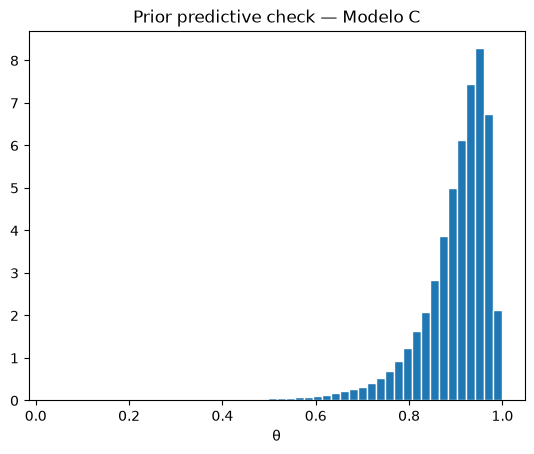

In [4]:
with modelo_C:
    prior_pred = pymc.sample_prior_predictive(samples = 1000, random_seed = 42)

theta_prior = prior_pred.prior['theta'].values
print('theta prior — media:', theta_prior.mean().round(4))
print('theta prior — rango:', theta_prior.min().round(4), theta_prior.max().round(4))

plt.hist(theta_prior.flatten(), bins = 50, density = True, edgecolor = 'white')
plt.xlabel('θ')
plt.title('Prior predictive check — Modelo C')
plt.show()


## 3.6 ¿Por qué `ZeroSumNormal`?

Las primeras versiones de este modelo, con `eff_inst ~ Normal(0, sigma)`, daban R-hat de 1.4-3 en todos los parámetros a pesar de correr sin errores. Tras investigar, detectamos que la causa del pobre desempeño era **no-identificabilidad**. En `logit(θ) = β0 + eff_inst[j]`, sumar una constante a `β0` y restársela a todos los `eff_inst` deja la verosimilitud exactamente igual — los datos solo identifican la *suma* `β0 + eff_inst[j]`, nunca cada término por separado. El posterior es una cresta diagonal infinita en vez de una montaña con un pico; cada cadena de MCMC converge a un punto distinto de esa cresta, lo que se traduce en R-hat altísimo.

**La solución:** `pm.ZeroSumNormal` impone la restricción de que la suma de los efectos de un grupo sea exactamente cero (p. ej. `eff_tipo[civil] + eff_tipo[militar] = 0`). Con esa restricción, `β0` queda matemáticamente identificado como el logit del promedio global, y cada efecto de grupo se interpreta directamente como una **desviación respecto a ese promedio**. Se aplica `ZeroSumNormal` a los cuatro componentes jerárquicos (`eff_tipo`, `dev_civil`/`dev_mil`, `eff_anio`, `eff_estado`). Con esta distribución el resultado fue R-hat < 1.001 en todos los parámetros con 0 divergencias.

---

## 3.7 Centered vs. non-centered

Un segundo problema apareció al usar parametros **non-centered** habituales en estadistica bayesiana. Considerando (`z ~ Normal(0,1)`, `eff = z * sigma`) con miles de observaciones e informando cada año/estado, el posterior de `sigma` es muy angosto y se genera un *funnel de Neal* (cuando `sigma` se acerca a valores pequeños, `z` puede tomar cualquier valor sin cambiar `z·sigma≈0`, creando un embudo que el sampler no puede recorrer con pasos de tamaño fijo). Fuente: https://num.pyro.ai/en/stable/examples/funnel.html


**La solución** fue usar parametrización **centrada** (`eff = ZeroSumNormal(sigma=sigma)` directamente, sin separar `z` y `sigma`). En nuestro caso, esta elección es adecuada ya que cada grupo tiene muchas observaciones, es decir miles de recetas por celda estado-año-institución.


---

## 3.8 Estructura anidada civil/militar

Institución está anidada dentro de tipo (IMSS, IMSS Bienestar e ISSSTE son "civil"; SEDENA y SEMAR son "militar"). Anidar con un solo `ZeroSumNormal` de 5 niveles perdería la estructura de bloque; usar `Normal(0, sigma)` para la desviación dentro de tipo reproduciría la misma no-identificabilidad de 3.6 entre `eff_tipo` y esa desviación. La solución fue usar **dos `ZeroSumNormal` separados**, uno por bloque:

```python
import pytensor.tensor as ptt  # pytensor.tensor, no pytensor directamente

sigma_tipo = pm.HalfNormal("sigma_tipo", sigma=0.5)
eff_tipo   = pm.ZeroSumNormal("eff_tipo", sigma=sigma_tipo, dims="tipo")

sigma_inst = pm.HalfNormal("sigma_inst", sigma=0.3)
dev_civil  = pm.ZeroSumNormal("dev_civil", sigma=sigma_inst, dims="inst_civil")  # suma 0 en {IMSS, IMSS Bienestar, ISSSTE}
dev_mil    = pm.ZeroSumNormal("dev_mil",   sigma=sigma_inst, dims="inst_mil")    # suma 0 en {SEDENA, SEMAR}

dev_dentro = pt.concatenate([dev_civil, dev_mil])          # longitud 5, alineado con `insts`
eff_inst   = pm.Deterministic("eff_inst", eff_tipo[inst_a_tipo] + dev_dentro, dims="institucion")
```

Esto deja a `eff_tipo[civil]` y `eff_tipo[militar]` identificados como el nivel promedio de cada bloque, y a `dev_civil`/`dev_mil` como la desviación de cada institución respecto al promedio de su propio tipo — la descomposición que permite, más adelante, hablar por separado de "brecha civil-militar" (estructural) y "ranking dentro del bloque civil" (institucional).

---

## 3.9 Supuestos explícitos del modelo

1. **Independencia condicional**: dado (estado, año, institución), las recetas dentro de esa celda son intercambiables, ya que no es posible desagregar por folio (microdatos).
2. **Suma de efectos escala logit**: los efectos de tipo, institución, año y estado se combinan sumando (no multplicando), por ejemplo, no se modela un efecto específico "SEDENA × 2021" distinto de sumar `eff_inst[SEDENA] + eff_anio[2021]`. Esto es una simplificación deliberada y anclada en los resultados usando distribuciones normales.
3. **Intercambios dentro de cada grupo jerárquico**: los 32 estados (o los 5 años) se tratan como intercambiables *a priori*, compartiendo una distribución común (`ZeroSumNormal(sigma)`) — es la base formal del *partial pooling* bayesiano.

---

## 3.10 Alcances y limitaciones

El modelo no captura interacciones estado×año (p. ej. un choque local en un estado en un año específico, más allá de los efectos principales). Tampoco incorpora variables de oferta (presupuesto ejercido, compras consolidadas) que podrían explicar parte la varianza entre años. Finalmente, depende de un solo indicador ("receta surtida en su totalidad") que puede subestimar el problema real en instituciones donde el personal médico evita prescribir medicamentos que sabe no están en existencia.

# 4. Resultados del modelo (performance)

In [5]:
with modelo_C:
    idata_test = pymc.sample(
        draws = 5000, tune = 1000, chains = 5,
        target_accept = 0.95, random_seed = 42,
        cores=5
    )
az.summary(idata_test, var_names = ['beta0', 'sigma_estado', 'sigma_anio', 'sigma_tipo', 'sigma_inst'])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 5 jobs)
NUTS: [beta0, sigma_estado, eff_estado, sigma_anio, eff_anio, sigma_tipo, eff_tipo, sigma_inst, dev_civil, dev_mil]


Output()

Sampling 5 chains for 1_000 tune and 5_000 draw iterations (5_000 + 25_000 draws total) took 25 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,2.133,0.001,2.132,2.134,0.000,0.000,29376.0,20554.0,1.0
sigma_estado,0.386,0.050,0.296,0.480,0.000,0.000,53845.0,16850.0,1.0
sigma_anio,0.575,0.128,0.354,0.818,0.001,0.001,57874.0,17442.0,1.0
sigma_tipo,0.869,0.248,0.446,1.335,0.001,0.002,57219.0,18538.0,1.0
sigma_inst,0.410,0.122,0.217,0.640,0.001,0.001,58704.0,18226.0,1.0


Sampling: [k_obs]


Output()

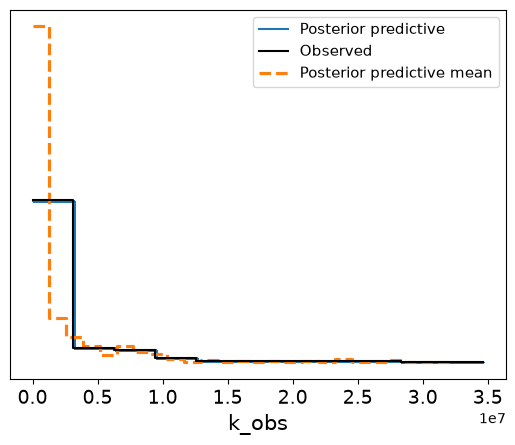

In [6]:
with modelo_C:
    post_pred_test = pymc.sample_posterior_predictive(idata_test, random_seed = 42)

az.plot_ppc(post_pred_test, observed_rug = True)
plt.show()


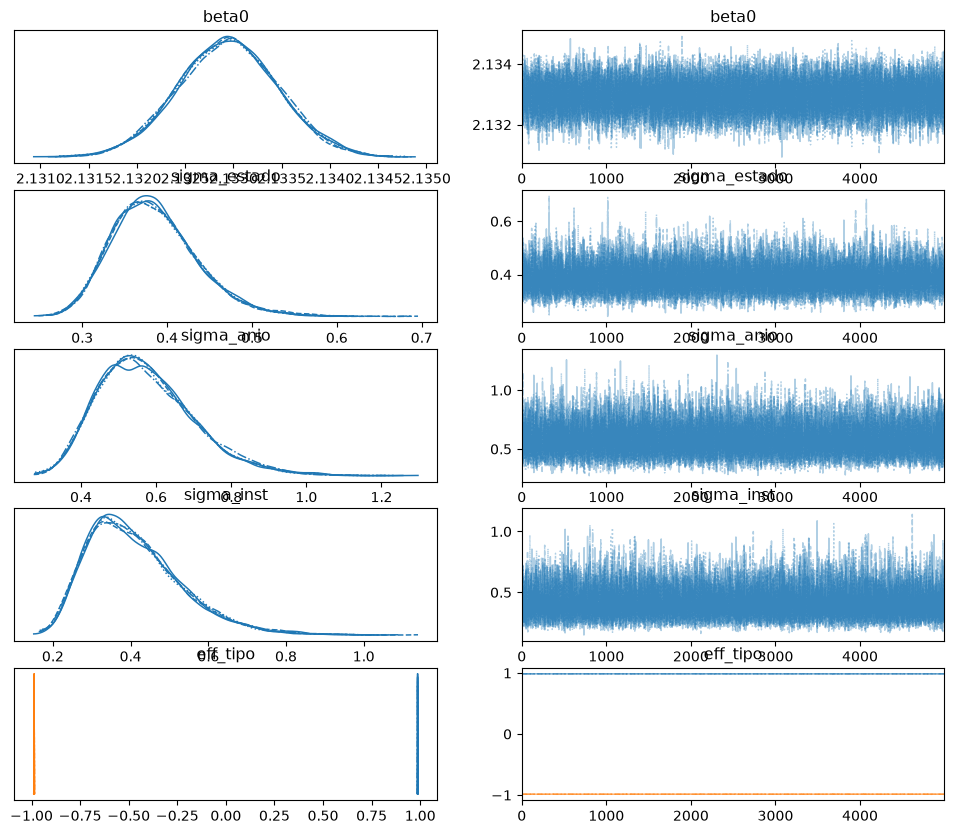

/Users/main/Documents/ciencia_de_datos/Programacion probabilistica/final-project-pp-dj/.venv/lib/python3.13/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (630) in plot_ess, generating only 40 plots
  warnings.warn(


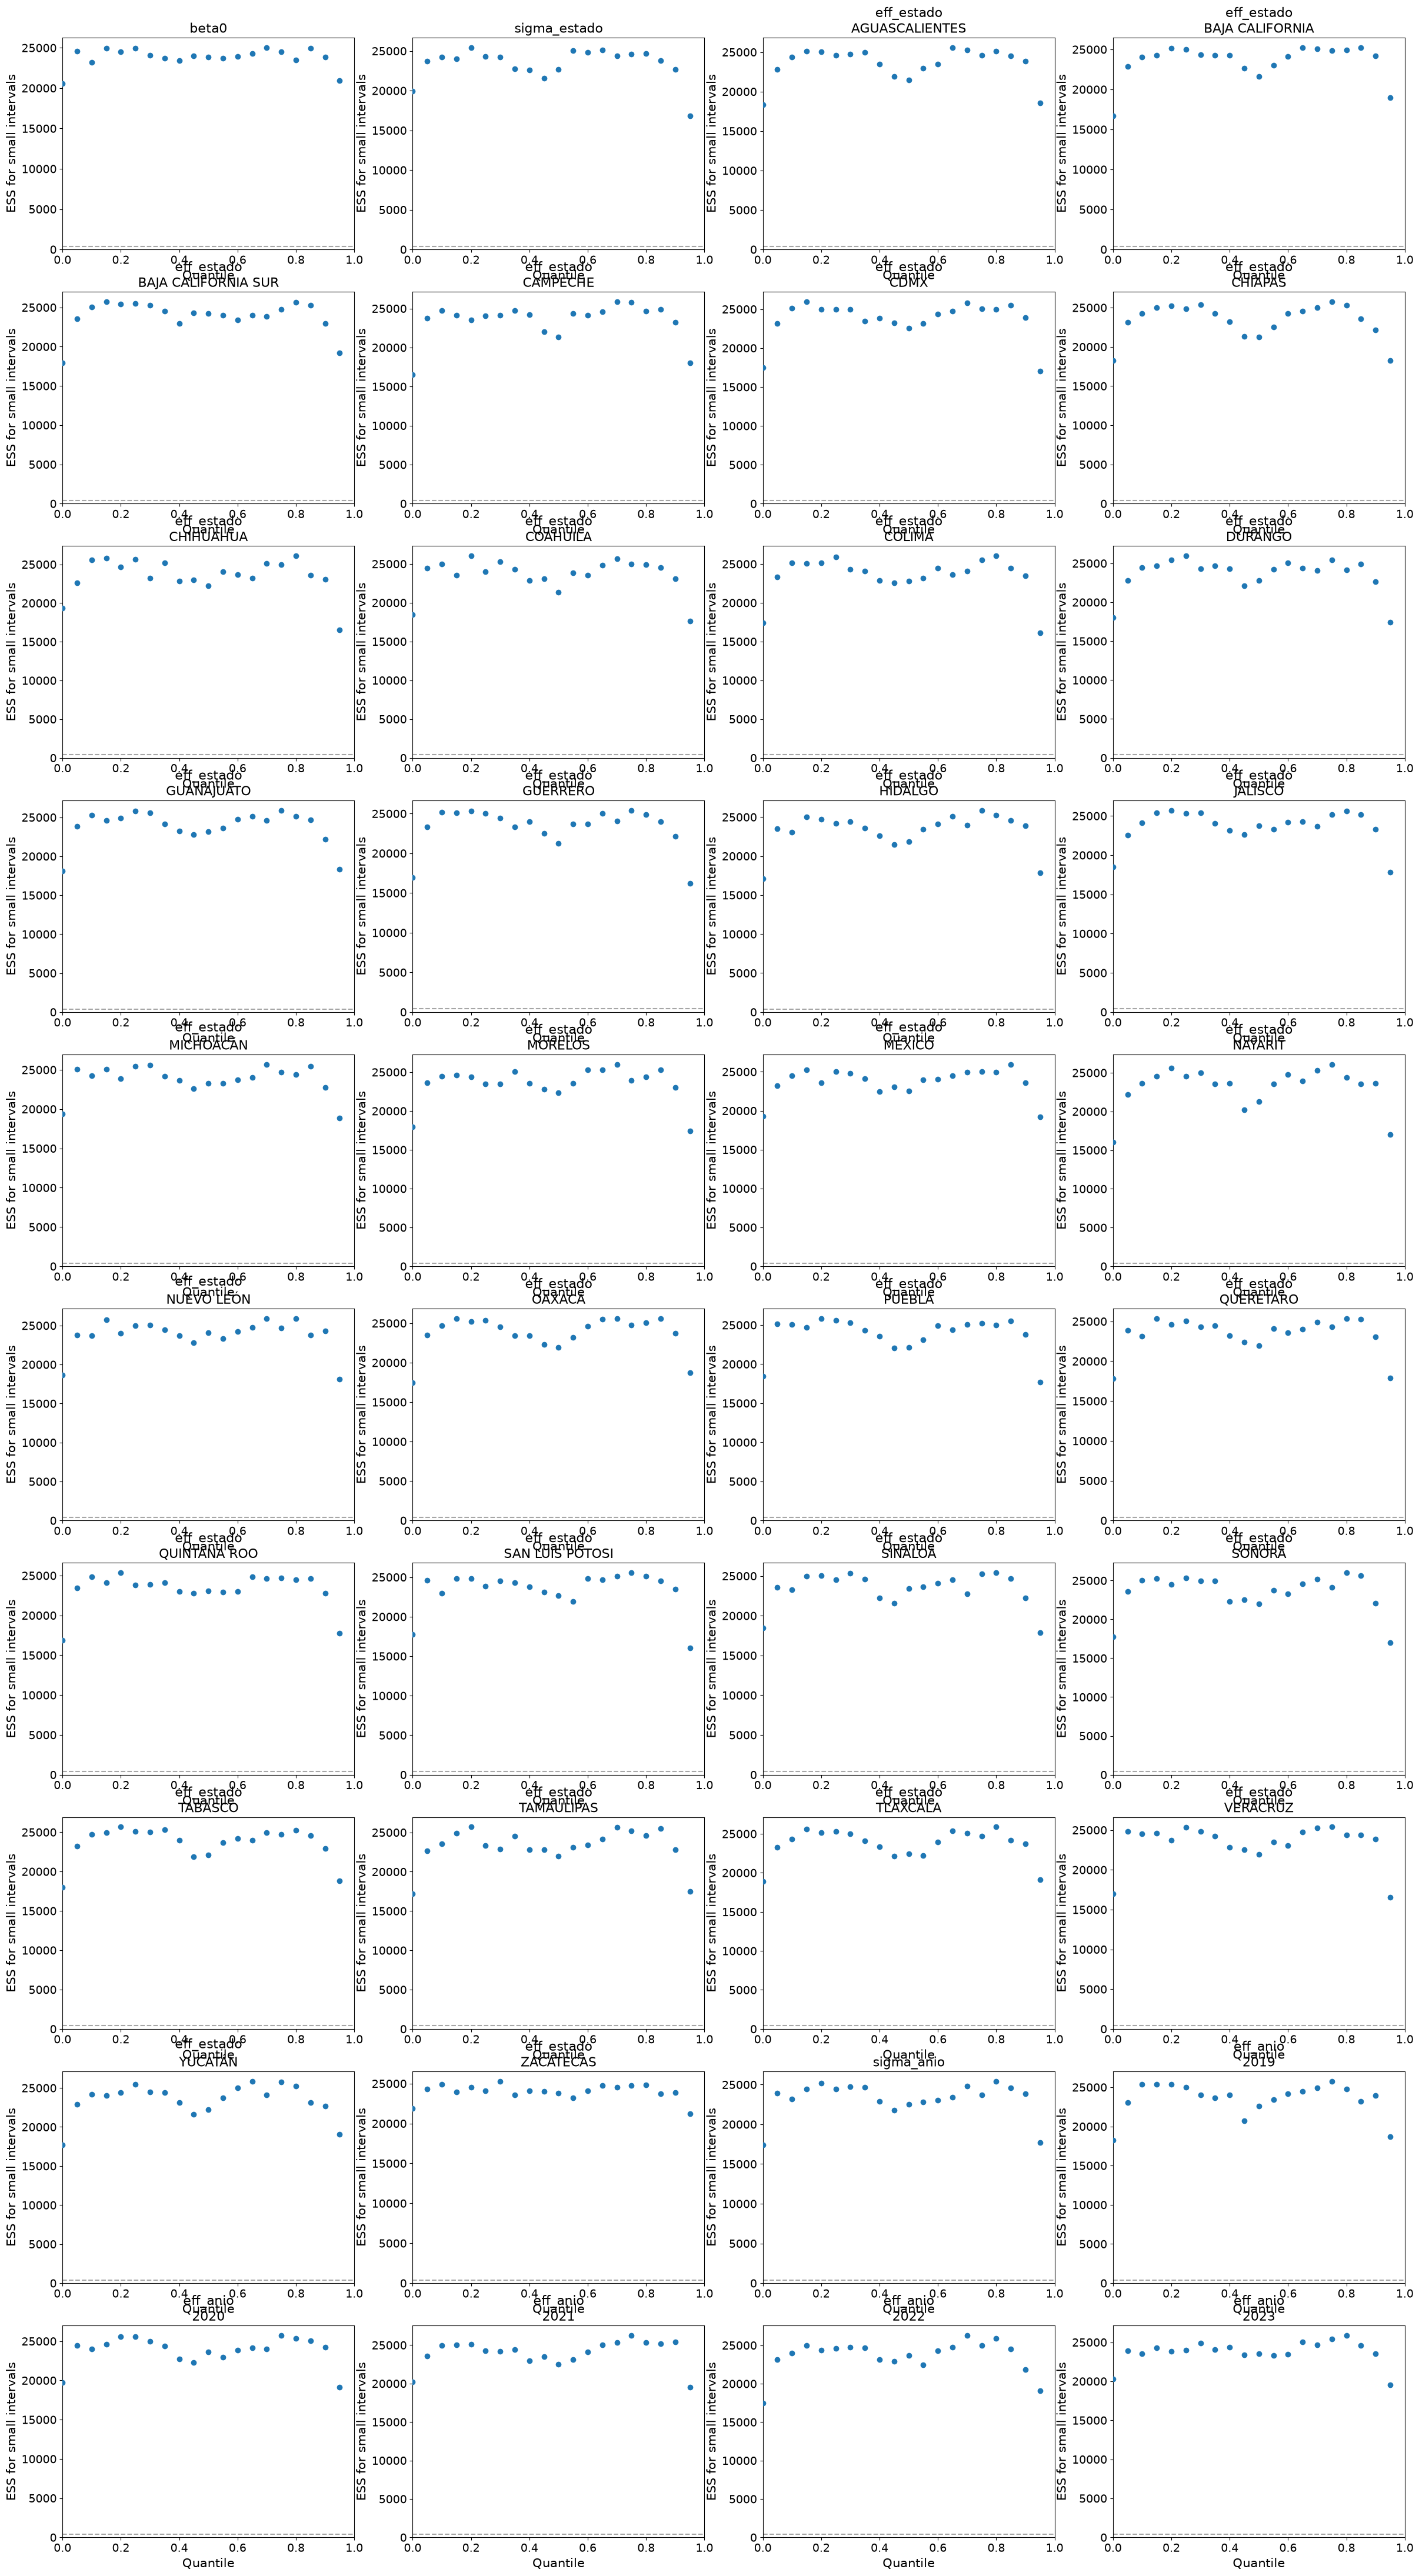

/Users/main/Documents/ciencia_de_datos/Programacion probabilistica/final-project-pp-dj/.venv/lib/python3.13/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (3150) in plot_autocorr, generating only 40 plots
  warnings.warn(


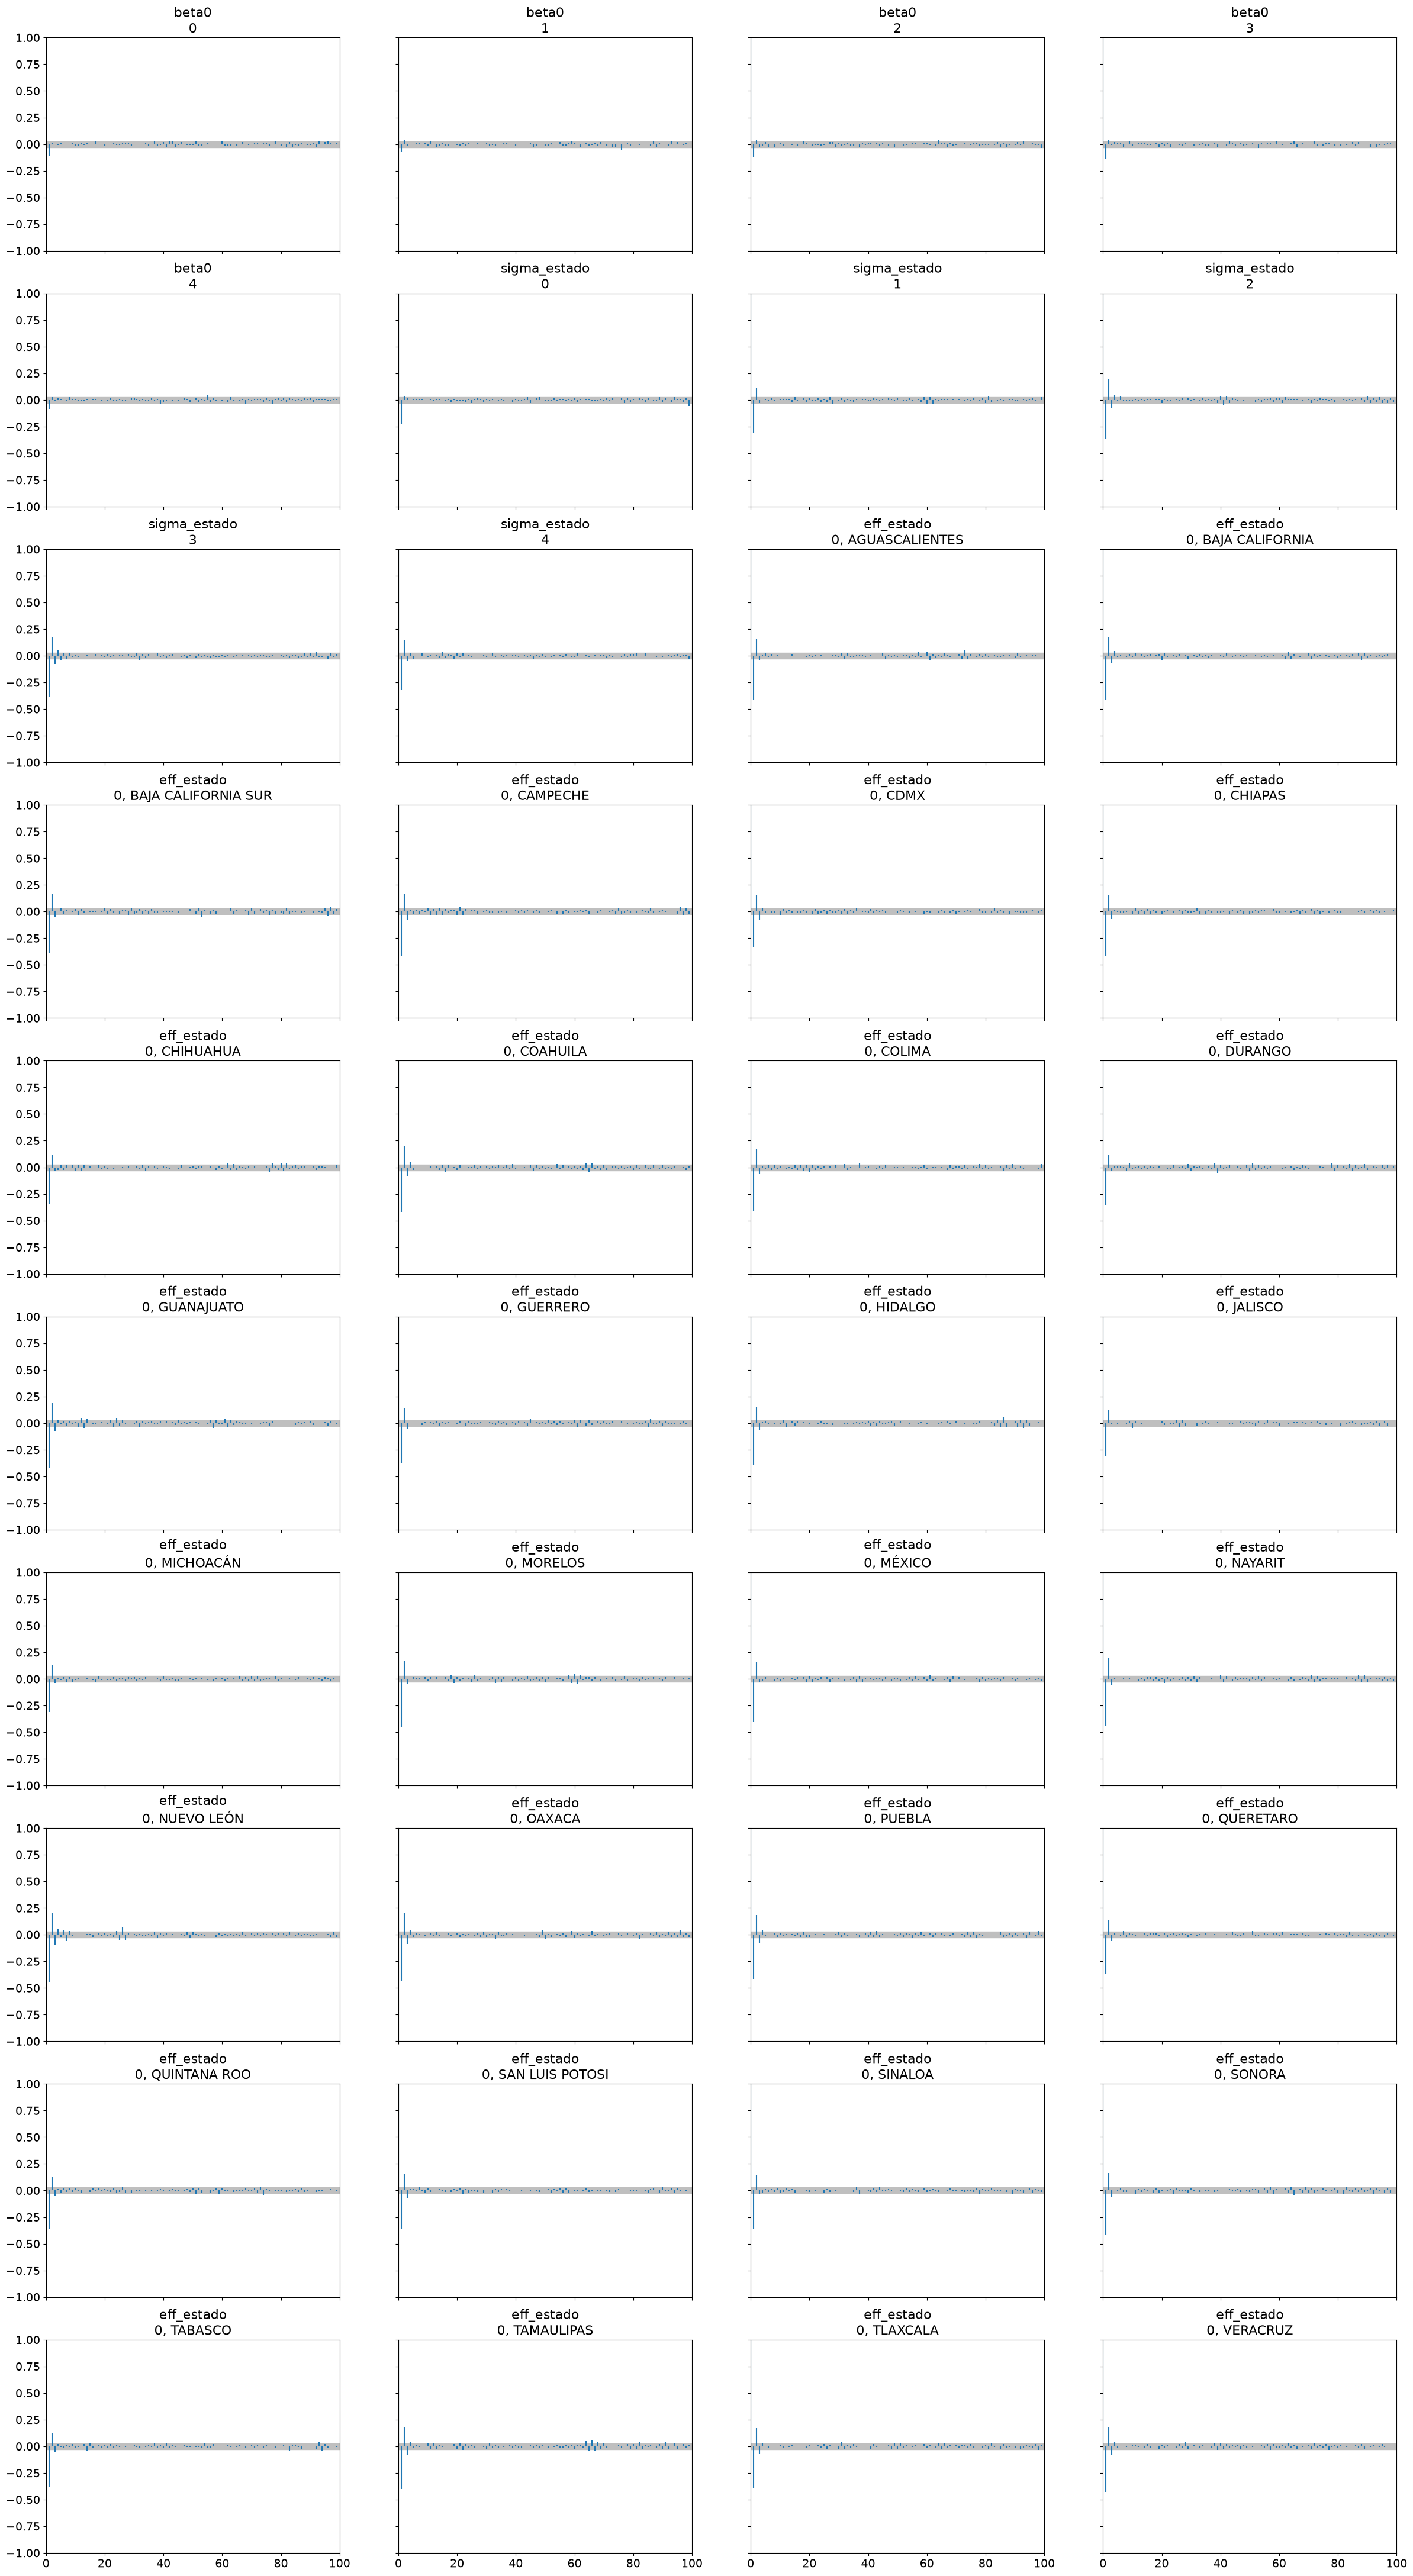

In [7]:
az.plot_trace(
    idata_test,
    var_names=["beta0", "sigma_estado", "sigma_anio", "sigma_inst", "eff_tipo"])
plt.show()
az.plot_ess(idata_test)
plt.show()
az.plot_autocorr(idata_test)
plt.show()

# 5. Interpretación de resultados e implicaciones de política pública

### Extracción del posterior

In [8]:
from analysis import *
from plots import *

post = extract_posterior(idata_test, data_c)

print('Keys en post:', list(post.keys()))
print('Instituciones:', post['insts'])
print('Tipos:', post['tipos'])


Keys en post: ['beta0', 'eff_inst', 'eff_anio', 'eff_estado', 'insts', 'estados', 'anios', 'eff_tipo', 'tipos']
Instituciones: ['IMSS', 'IMSS Bienestar', 'ISSSTE', 'SEDENA', 'SEMAR']
Tipos: ['civil', 'militar']


## 5.1 Promedio global: el punto de referencia del accesso a medicamentos 

β0 = 2.133  →  θ_global = 89.4%

---

Antes de considerar institución, año o estado, la probabilidad promedio de que un paciente reciba todos sus medicamentos es 89.4%.

--- 

**Esto implica que , 1 de cada 10 pacientes sale con receta incompleta en promedio nacional**.

In [9]:
az.summary(idata_test, var_names = ['beta0'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,2.133,0.001,2.132,2.134,0.0,0.0,29376.0,20554.0,1.0


## 5.2 Jerarquía de efectos (fuentes de varianza)

Los parámetros sigma cuantifican cuánta variación explica cada dimensión del modelo.  
**Tipo (civil/militar)** es el factor dominante — más que estados o años.

Interpretación de σ:
  σ_tipo    = 0.869 → diferencia civil/militar domina el sistema
  σ_anio    = 0.575 → variación año a año (COVID visible)
  σ_inst    = 0.410 → diferencias dentro de cada bloque
  σ_estado  = 0.386 → geografía: importante pero no dominante


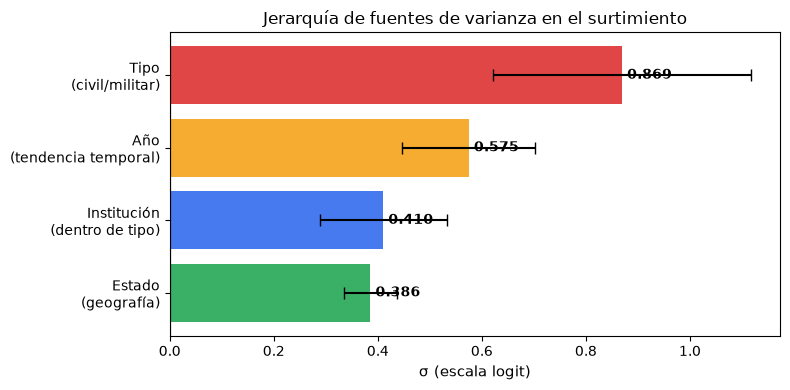

In [10]:
from plots_jmv import *

plot_varianzas(idata_test)
plt.show()



## 5.3  La brecha civil-militar — el hallazgo más fuerte
|Bloque|	θ estimada|	IC 97.5%|
|---|---:|---:|
|Civil (IMSS, ISSSTE, IMSS Bienestar)|	95.7%|	[95.7%, 95.7%]|
|Militar (SEDENA, SEMAR)|	75.9%	|[75.8%, 75.9%]|

---

Brecha	~20 puntos porcentuales	
sigma_tipo = 0.869 es el componente de varianza más grande del modelo — la división civil/militar explica más variación que estados o años combinados. 

---

**Esto es el hallazgo central de política pública: el sistema de salud militar tiene una crisis de desabasto estructuralmente distinta a la del sistema civil.**


=== Brecha civil/militar ===


,tipo,theta_media,ic_2.5,ic_97.5
0,civil,0.957687,0.957656,0.957719
1,militar,0.758861,0.758519,0.759201


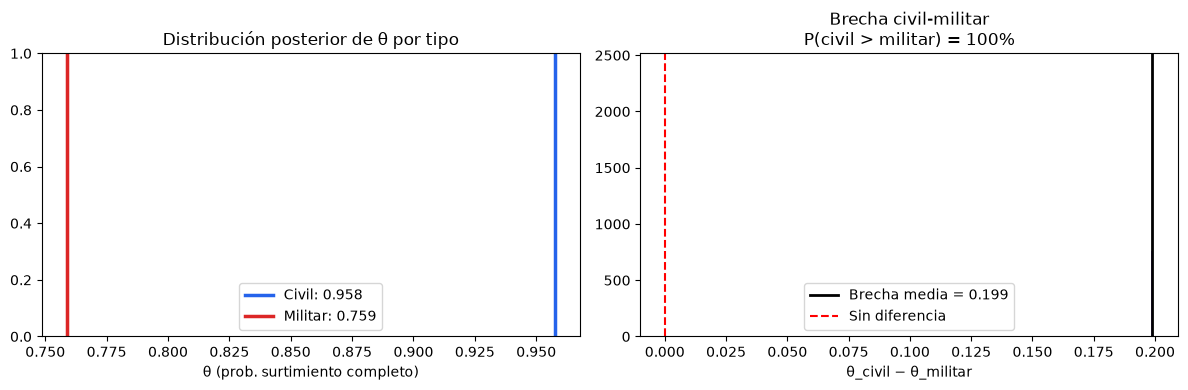

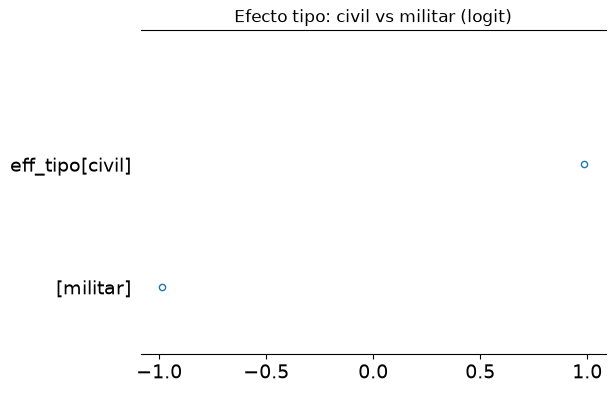

In [11]:
# Brecha civil vs militar

print('=== Brecha civil/militar ===')
display(brecha_civil_militar(post))

plot_brecha_civil_militar(post)
plt.show()

az.plot_forest(idata_test, var_names=["eff_tipo"], combined=True)
plt.title("Efecto tipo: civil vs militar (logit)")
plt.show()



## 5.4 Ranking de instituciones

ISSSTE supera al IMSS a pesar de ser menos discutido públicamente. IMSS Bienestar (antes Seguro Popular) está en medio — no llega a las instituciones civiles consolidadas pero tampoco cae al nivel militar.

| Institución    | θ estimada | Interpretación                                              |
|----------------|-----------:|--------------------------------------------------------------|
| ISSSTE         | 97.5%      | La mejor del sistema — solo 2.4% con receta incompleta       |
| IMSS           | 95.1%      | Robusto a pesar de ser el sistema más grande                 |
| IMSS Bienestar | 93.6%      | Menor que IMSS/ISSSTE — población más vulnerable             |
| SEMAR          | 76.8%      | Crisis severa — 1 de cada 4 pacientes sale incompleto         |
| SEDENA         | 74.8%      | Peor del sistema — casi 1 de cada 4 pacientes                 |



=== Ranking instituciones ===


,institucion,theta_media,ic_2.5,ic_97.5,receta_incompleta
0,ISSSTE,0.975630,0.975606,0.975654,0.024370
1,IMSS,0.951287,0.951270,0.951304,0.048713
2,IMSS Bienestar,0.936832,0.936711,0.936953,0.063168
3,SEMAR,0.768622,0.768102,0.769133,0.231378
4,SEDENA,0.748822,0.748397,0.749249,0.251178


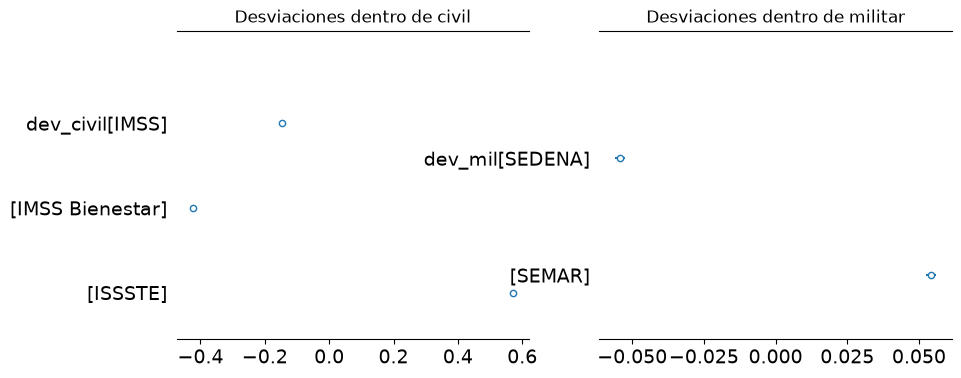

In [12]:
print('=== Ranking instituciones ===')
display(ranking_instituciones(post))


# Desviaciones dentro de cada tipo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
az.plot_forest(idata_test, var_names=["dev_civil"], combined=True, ax=axes[0])
az.plot_forest(idata_test, var_names=["dev_mil"],   combined=True, ax=axes[1])
axes[0].set_title("Desviaciones dentro de civil")
axes[1].set_title("Desviaciones dentro de militar")
plt.show()



## 5.5 Geografía del desabasto

---

### 5.5.1 Estados con mejor desempeño relativo:

| Estado              | Efecto | Interpretación                                          |
|----------------------|-------:|-----------------------------------------------------------|
| CDMX                 | +1.06  | El outlier positivo más claro; concentración de infraestructura y personal |
| Baja California Sur  | +0.82  | Pequeño y accesible logísticamente                        |
| Aguascalientes       | +0.58  | Estado pequeño, bien comunicado                           |

---

### 5.5.2 Estados con peor desempeño relativo:

| Estado          | Efecto | Interpretación                                     |
|------------------|-------:|-------------------------------------------------------|
| Chihuahua        | −0.71  | El outlier negativo más pronunciado; territorio extenso, frontera |
| Tabasco          | −0.52  | Problemas logísticos, calor, distribución regional     |
| Coahuila y Oaxaca| −0.38  | Dispersión geográfica                                  |

---

### 5.5.3 Estados con problema estructural confirmado (P(eff_estado<0) > 95%)

|   |       |    |
|------------|-----------------|--------------|
| Chihuahua  | Zacatecas       | Chiapas      |
| Tabasco    | San Luis Potosí | Hidalgo      |
| Coahuila   | Durango         | Tamaulipas   |
| Oaxaca     | Sonora          | Tlaxcala     |
| Michoacán  | Morelos         | Nuevo León   |
| Campeche   | Yucatán         | Queretaro    |


El efecto estado es compartido por todas las instituciones. En estos estados, IMSS, ISSSTE e IMSS Bienestar están simultáneamente por debajo del promedio nacional — señal de problema territorial no institucional.


=== Estados con problemas estructurales (umbral 0.95) ===


,estado,eff_estado_media,ic_2.5,ic_97.5,p_eff_negativo
0,CHIHUAHUA,-0.708562,-0.709457,-0.707678,1.0
1,TABASCO,-0.518698,-0.520664,-0.516729,1.0
2,COAHUILA,-0.382007,-0.383090,-0.380903,1.0
3,OAXACA,-0.380815,-0.382690,-0.378950,1.0
4,MICHOACÁN,-0.348288,-0.349451,-0.347116,1.0
5,CAMPECHE,-0.298858,-0.301411,-0.296288,1.0
6,QUERETARO,-0.273918,-0.275548,-0.272264,1.0
7,ZACATECAS,-0.272626,-0.274441,-0.270799,1.0
8,SAN LUIS POTOSI,-0.270124,-0.271526,-0.268727,1.0
9,DURANGO,-0.249472,-0.250979,-0.247982,1.0


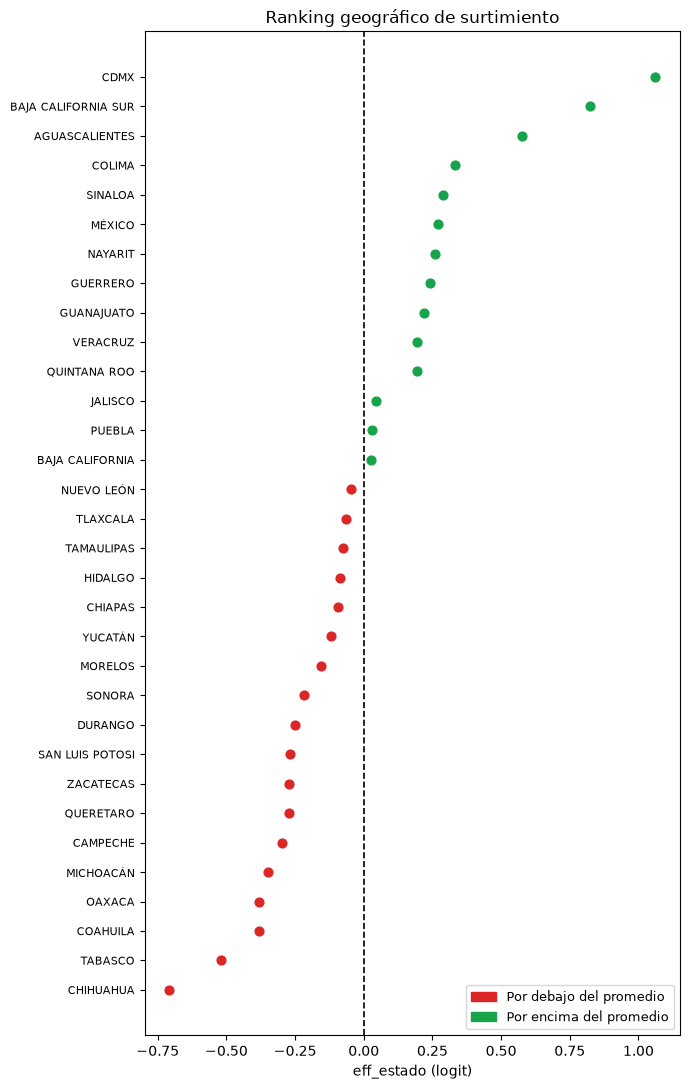

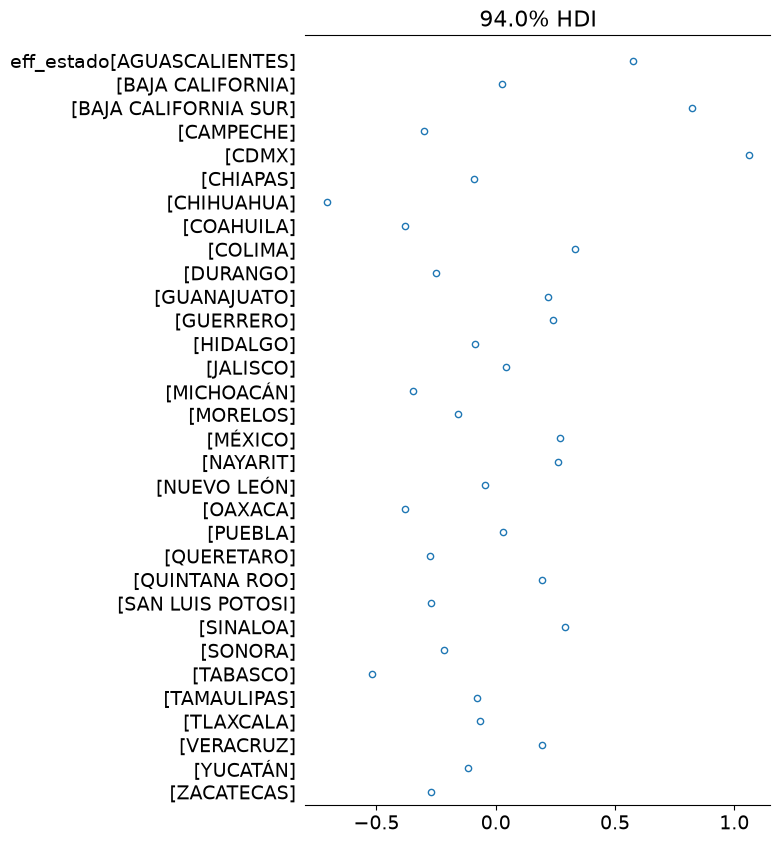

In [13]:
# Efecto de cada estado (ranking geográfico)

print('=== Estados con problemas estructurales (umbral 0.95) ===')
display(estados_estructurales(post))

plot_ranking_geografico(post)
plt.show()

az.plot_forest(idata_test, var_names=["eff_estado"], combined=True, figsize=(6, 10))
plt.show()


## 5.6 Tendencia temporal — el impacto del COVID-19

| Año  | Efecto (logit) | Interpretación                                        |
|------|----------------:|----------------------------------------------------------|
| 2019 | +0.692          | Línea base — mejor año del período                       |
| 2020 | −0.523          | Caída COVID (−1.21 logits vs 2019)                        |
| 2021 | −0.792          | Peor año — pico COVID + reestructura INSABI               |
| 2022 | −0.128          | Recuperación parcial, sigue bajo 2019                     |
| 2023 | +0.749          | Casi recuperado — ligeramente mejor que 2019              |


--- 

El efecto anual tiene `sigma_anio` = 0.575 — la segunda fuente de varianza más grande. La caída de 2019 a 2021 representa una pérdida de ~1.48 logits, equivalente a bajar aproximadamente 10-12 puntos porcentuales en la tasa nacional de surtimiento.

--- 

Hallazgo: el sistema se recuperó en 2023, pero la reestructuración institucional (INSABI/IMSS Bienestar) dejó huella visible en 2020-2022.

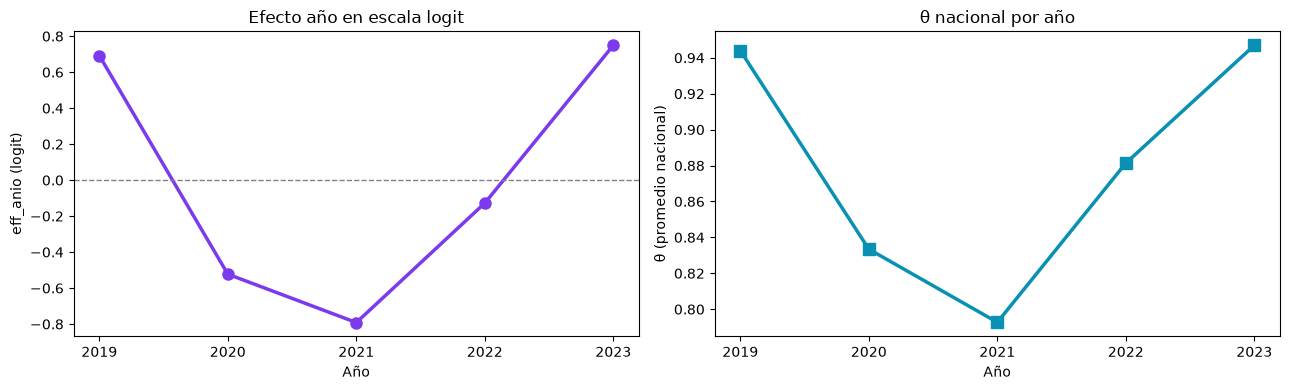

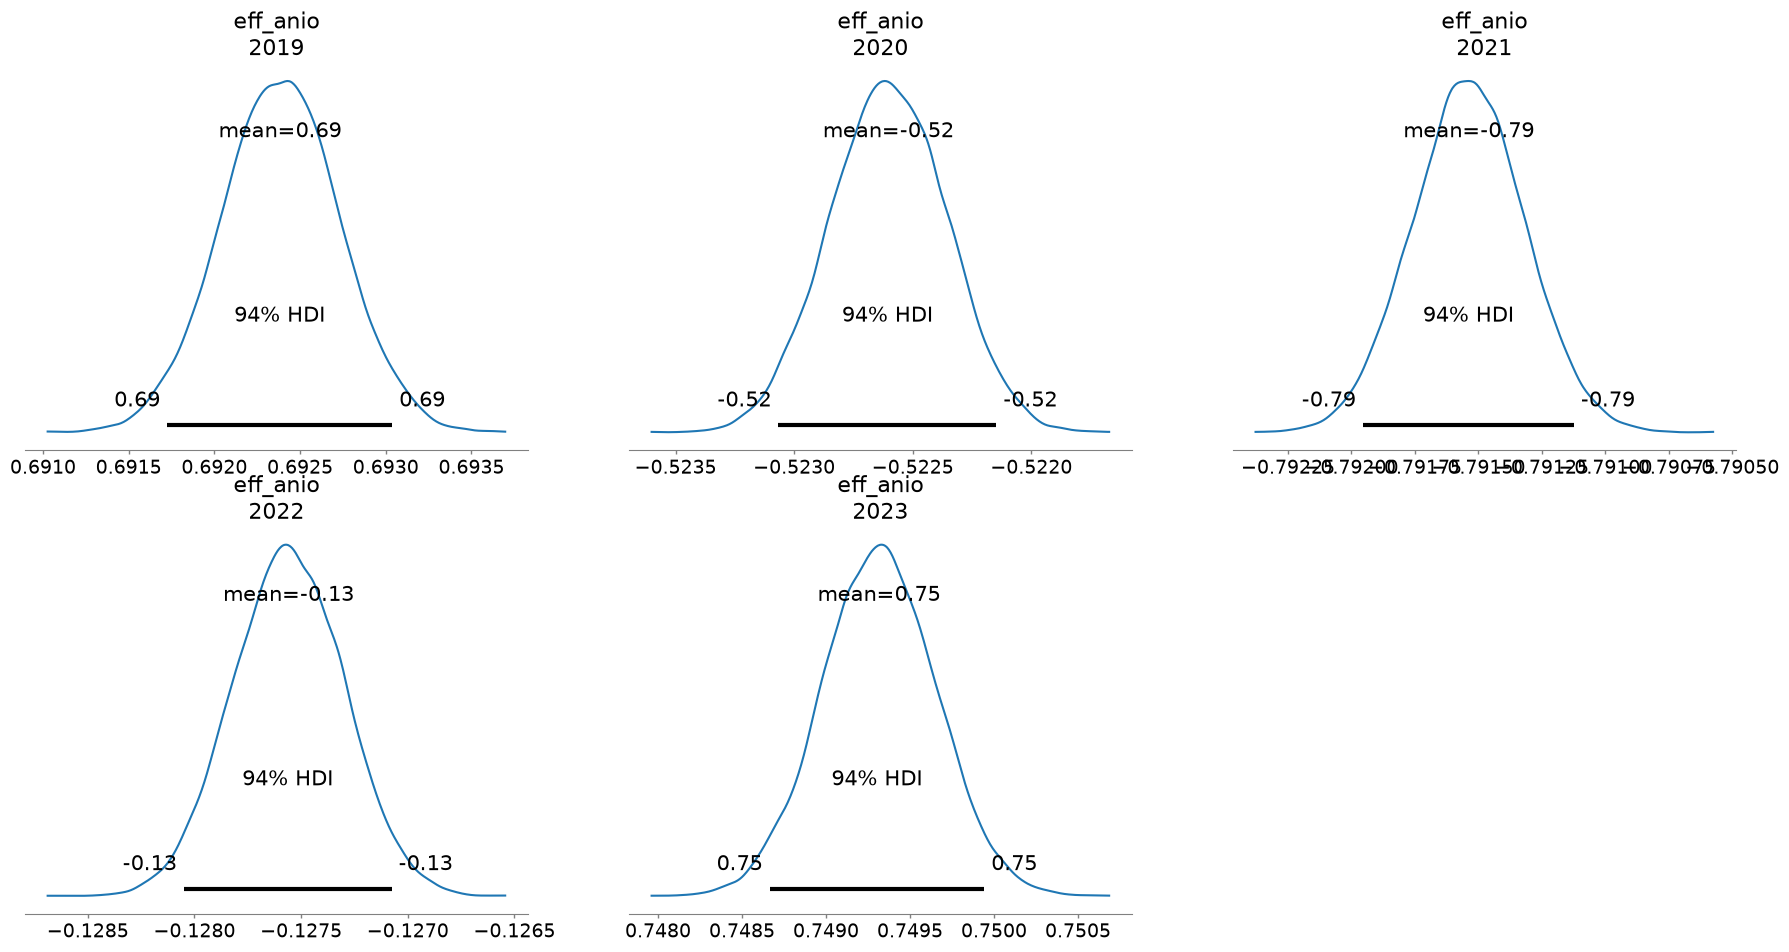

In [14]:
# Tendencia temporal


plot_tendencia_anual(post)
plt.show()

az.plot_posterior(idata_test, var_names=["eff_anio"])
plt.show()


# 5.7 Escenarios críticos — peor estado × peor año

El año 2021 (peor año) combinado con los estados de mayor desabasto produce las estimaciones más preocupantes del análisis.

Chihuahua es el estado con mayor desabasto estructural (eff_estado = −0.71): en el peor año (2021), el 18.7% de los pacientes del IMSS salió sin toda su medicación.

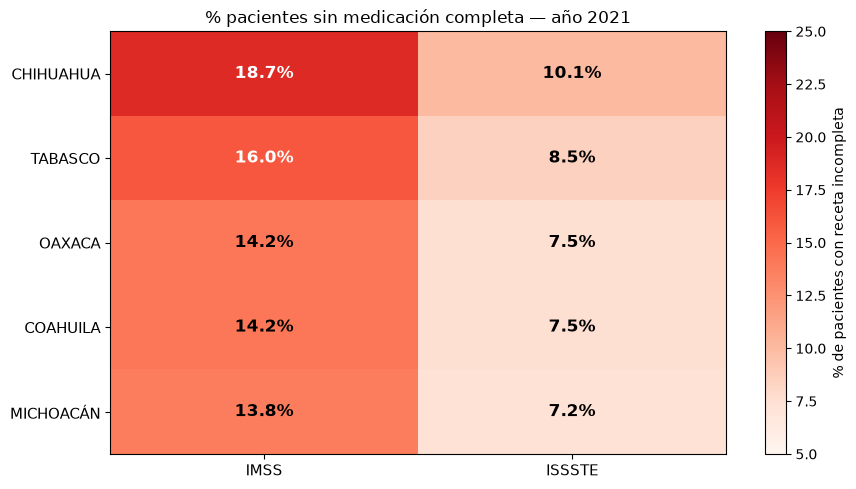

In [15]:
plot_escenarios_criticos(
    post,
    estados = ['CHIHUAHUA', 'TABASCO', 'OAXACA', 'COAHUILA', 'MICHOACÁN'],
    instituciones = ['IMSS', 'ISSSTE'],
    anio = 2021,
    theta_posterior_fn = theta_posterior,
)
plt.show()


# 5.8 Resumen de principales hallazgos 

1. P(sistema civil > sistema militar) = 100%
   El sistema civil surte al 95.8% de los pacientes; el militar al 75.9%. La brecha es de 19.9% puntos porcentuales.

2. P(ISSSTE > IMSS en surtimiento) = 100%
   A pesar de ser la institución menos discutida públicamente, el ISSSTE (97.6%) supera al IMSS (95.1%) con certeza total.

3. Chihuahua 2021 (IMSS): P(receta incompleta) = 18.7%
   El peor escenario del período: casi 1 de cada 5 pacientes del IMSS en Chihuahua salió con su receta incompleta en el peor año del COVID.

4. 18 estados con problema estructural confirmado (P(eff_estado<0) > 95%)
   El efecto estado es compartido por todas las instituciones. En estos estados, IMSS, ISSSTE e IMSS Bienestar están simultáneamente por debajo del promedio nacional — señal de problema territorial, no institucional.

5. Fuente de varianza dominante: tipo civil/militar (σ_tipo = 0.869 vs σ_estado = 0.386)
   La brecha civil-militar explica más variación en el surtimiento que la heterogeneidad geográfica entre estados. El sistema de salud militar enfrenta una crisis estructural diferente y más severa que el sistema civil.

## 5.9 Recomendaciones de política pública 

Los resultados del modelo apuntan a intervenciones concretas y acotadas, más que a una reforma general del sistema de salud:

1. **Tratar al sistema militar como un problema aparte, no como "el mismo problema con menos presupuesto".** Dado que `sigma_tipo` (0.869) es la mayor fuente de varianza del modelo y que SEDENA (74.8%) y SEMAR (76.8%) están muy por debajo incluso de la institución civil más débil (IMSS Bienestar, 93.6%), la brecha no se explica por diferencias graduales sino por una falla estructural distinta en la cadena de suministro militar. Una auditoría específica de esa cadena (no una extensión del protocolo civil) es el punto de partida más costo-efectivo.

2. **Focalizar la logística de distribución en los estados con problema compartido entre instituciones civiles, no solo en la institución con peor cifra.** En los 18 estados donde IMSS, ISSSTE e IMSS Bienestar caen simultáneamente por debajo del promedio nacional (Chihuahua a la cabeza, con un efecto de −0.71 y 18.7% de recetas incompletas en el peor escenario observado, IMSS-Chihuahua 2021), el patrón indica un cuello de botella territorial —no institucional—, por lo que la solución más directa es reforzar puntos de distribución regionales compartidos en esos estados, en vez de negociar abasto institución por institución.

3. **Instrumentar un protocolo de continuidad de abasto durante transiciones administrativas.** La caída de surtimiento de 2019 a 2021 (equivalente a ~10-12 puntos porcentuales) coincide con la desaparición del Seguro Popular y la creación del INSABI, y el sistema no se recuperó del todo sino hasta 2023. Con la transición en curso de IMSS-Bienestar a Organismo Público Descentralizado, este mismo riesgo es previsible y monitoreable: vale la pena dar seguimiento trimestral al surtimiento de esa institución específica durante el proceso, en vez de esperar a medir el impacto hasta que ya ocurrió.



# 6. El rol de la incertidumbre y áreas de oportunidad

## 7. GLM binomial logit (baseline frecuentista)


Equivalente frecuentista del Modelo A y C: efectos fijos para estado, año
e institución, sin pooling parcial. Sirve como punto de comparación con
el modelo bayesiano jerárquico.


In [16]:
from logit_frecuente import fit_logit_a, fit_logit_c, resumen_coeficientes

result_a = fit_logit_a(df)
result_c = fit_logit_c(df)

print(result_a.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                   prop   No. Observations:                  415
Model:                            GLM   Df Residuals:               1310833705
Model Family:                Binomial   Df Model:                           37
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8325e+08
Date:                Thu, 02 Jul 2026   Deviance:                   5.5042e+06
Time:                        06:36:08   Pearson chi2:                 5.63e+06
No. Iterations:                    11   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [17]:
print(result_c.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   prop   No. Observations:                  576
Model:                            GLM   Df Residuals:               1318600758
Model Family:                Binomial   Df Model:                           39
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8645e+08
Date:                Thu, 02 Jul 2026   Deviance:                   6.6238e+06
Time:                        06:36:08   Pearson chi2:                 6.92e+06
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

### Coeficientes en tabla limpia

In [18]:
res_a = resumen_coeficientes(result_a)
res_c = resumen_coeficientes(result_c)
print('=== Modelo A (civiles) ===')
display(res_a[res_a['variable'].str.contains('institucion|anio|Intercept')])

print('=== Modelo C (civil + militar) ===')
display(res_c[res_c['variable'].str.contains('institucion|anio|Intercept')])

=== Modelo A (civiles) ===


,variable,coef,ic_2.5,ic_97.5,p_valor,theta
0,Intercept,4.250172,4.247707,4.252637,0.0,0.999797
32,C(anio)[T.2020],-1.227940,-1.228891,-1.226988,0.0,0.953568
33,C(anio)[T.2021],-1.507815,-1.508735,-1.506896,0.0,0.939480
34,C(anio)[T.2022],-0.831425,-0.832405,-0.830445,0.0,0.968285
35,C(anio)[T.2023],0.086457,0.085315,0.087599,0.0,0.987088
36,C(institucion)[T.IMSS Bienestar],-0.266748,-0.268811,-0.264684,0.0,0.981719
37,C(institucion)[T.ISSSTE],0.716963,0.715926,0.718000,0.0,0.993085


=== Modelo C (civil + militar) ===


,variable,coef,ic_2.5,ic_97.5,p_valor,theta
0,Intercept,4.239001,4.236540,4.241463,0.0,0.999792
32,C(anio)[T.2020],-1.214985,-1.215929,-1.214041,0.0,0.953647
33,C(anio)[T.2021],-1.483921,-1.484832,-1.483009,0.0,0.940200
34,C(anio)[T.2022],-0.819940,-0.820910,-0.818971,0.0,0.968295
35,C(anio)[T.2023],0.056930,0.055814,0.058047,0.0,0.986559
36,C(institucion)[T.IMSS Bienestar],-0.275168,-0.277228,-0.273107,0.0,0.981364
37,C(institucion)[T.ISSSTE],0.717874,0.716837,0.718910,0.0,0.993014
38,C(institucion)[T.SEDENA],-1.879527,-1.881823,-1.877232,0.0,0.913684
39,C(institucion)[T.SEMAR],-1.771315,-1.774225,-1.768404,0.0,0.921845
